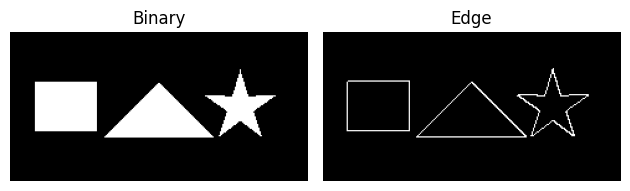

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from skimage.draw import polygon

X = np.array([(0,0), (0,1), (1,0), (1,1)])
y = np.array([0,1,1,0])

mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic', max_iter=1000, random_state=0, solver='lbfgs')
mlp.fit(X,y)

img = np.zeros((120, 240), dtype=int)
img[40:80, 20:70]=1
for i in range(45):
    img[40+i, 120-i:120+i]=1


angles = np.linspace(-np.pi/2, 1.5*np.pi, 11)
radii = [30,11]*5 + [30]
rr, cc = polygon(60 + np.sin(angles)*radii, 185 + np.cos(angles)*radii)
img[rr.astype(int), cc.astype(int)]=1

flat_img = img.flatten()

edge_right = mlp.predict(np.c_[flat_img, np.roll(img, -1, axis=1).flatten()])
edge_down = mlp.predict(np.c_[flat_img, np.roll(img, -1, axis=0).flatten()])
edges = (edge_right | edge_down). reshape(img.shape)

plt.subplot(1,2,1); plt.imshow(img,cmap='gray'); plt.title("Binary"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(edges,cmap='gray'); plt.title("Edge"); plt.axis('off')
plt.tight_layout()
plt.show()
